## Model1_Baseline_CNN.ipynb — Group 15 | 7PAM2033
## Model     : Baseline Convolutional Neural Network (CNN)
## Dataset   : MRI_Augmented (balanced — 4 classes)
## Purpose   : Train a CNN from scratch as our baseline model.
##             Results from this model are compared against Model 2 (Transfer
##             Learning) and Model 3 (Hybrid Multimodal) in the final report.
 

In [15]:
# ================================================================================
# CELL 1 — Import all required libraries
# ================================================================================
 
import os
import random
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
 
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
 
# Suppress noisy warnings that clutter the output
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
 
# Use logging so we can see INFO vs WARNING messages separately
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

 
# Fix seeds for reproducibility — ensures same results every run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
 
# Apply consistent plot style across all figures
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
})
 
logger.info("Libraries loaded. TensorFlow version: %s", tf.__version__)
 
 

INFO | Libraries loaded. TensorFlow version: 2.21.0


In [16]:

# ================================================================================
# CELL 2 — Set all paths and hyperparameters in one place
# ================================================================================
# All settings are here so they are easy to find and change without
# digging through the rest of the code
 
# UPDATE this path to match your local dataset location
DATA_DIR    = Path("../Data/MRI_Augmented")   # balanced dataset from EDA
RESULTS_DIR = Path("../results")
MODELS_DIR  = Path("../results/models")
PLOTS_DIR   = Path("../results/plots")
 
# Create output folders if they don't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
 
# The 4 dementia stages — order matches folder names
CLASSES   = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]
N_CLASSES = len(CLASSES)
 
# Image settings — must match what was set in EDA resizing cell
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
IMG_SIZE    = (IMG_HEIGHT, IMG_WIDTH)
IMG_SHAPE   = (IMG_HEIGHT, IMG_WIDTH, 3)   # 3 channels = RGB
 
# Training hyperparameters
BATCH_SIZE  = 32
EPOCHS      = 50      # EarlyStopping will stop before this if needed
VAL_SPLIT   = 0.15    # 15% of training data used for validation
TEST_SPLIT  = 0.15    # 15% held out as test set
LEARN_RATE  = 0.001
 
logger.info("Paths and hyperparameters configured.")
logger.info("DATA_DIR = %s", DATA_DIR.resolve())
 

INFO | Paths and hyperparameters configured.
INFO | DATA_DIR = C:\Users\SOFTWARE POINT\Desktop\WEEK-4\Data\MRI_Augmented


In [17]:

# ================================================================================
# CELL 3 — Validate the dataset folder before loading
# ================================================================================
# Check the folder exists and has the expected class subfolders
# before spending time on data loading
 
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR.resolve()}\n"
        "Please update DATA_DIR to point to your MRI_Augmented folder."
    )
 
# Count images per class so we know what the model is training on
print("Images available per class:")
print("-" * 40)
total_images = 0
for cls in CLASSES:
    cls_path = DATA_DIR / cls
    if cls_path.exists():
        n = len(list(cls_path.glob("*.jpg")) +
                list(cls_path.glob("*.jpeg")) +
                list(cls_path.glob("*.png")))
        print(f"  {cls:<22}: {n:>5}")
        total_images += n
    else:
        logger.warning("Class folder missing: %s", cls_path)
 
print(f"\n  Total images: {total_images:,}")

Images available per class:
----------------------------------------


  NonDemented           :  6528
  VeryMildDemented      :  6528
  MildDemented          :  6528
  ModerateDemented      :  6528

  Total images: 26,112


In [18]:

# ================================================================================
# CELL 4 — Create train, validation and test data generators
# ================================================================================
# We use ImageDataGenerator to load images in batches so we don't run out of memory.
# Training generator applies mild augmentation to further reduce overfitting.
# Validation and test generators only rescale — no augmentation.
# Note: we already did offline augmentation in EDA, but online augmentation
# during training adds extra variety and prevents the model memorising the data.
 
# Training data generator with mild online augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,            # normalise pixel values from 0-255 to 0-1
    rotation_range=10,             # slight rotation
    width_shift_range=0.05,        # small horizontal shift
    height_shift_range=0.05,       # small vertical shift
    horizontal_flip=True,          # random horizontal flip
    zoom_range=0.05,               # slight zoom
    validation_split=VAL_SPLIT     # reserve 15% for validation
)
 
# Validation and test generators — only rescale, no augmentation
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)
 
# Training generator — uses training subset of MRI_Augmented
train_gen = train_datagen.flow_from_directory(
    str(DATA_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",     # one-hot encoded labels for 4 classes
    classes=CLASSES,              # enforce consistent class ordering
    subset="training",            # use training split
    shuffle=True,
    seed=SEED
)
 
# Validation generator — uses validation subset
val_gen = train_datagen.flow_from_directory(
    str(DATA_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASSES,
    subset="validation",          # use validation split
    shuffle=False,                # don't shuffle — needed for consistent evaluation
    seed=SEED
)
 
# Test generator — loads from same folder but with no split (we use all for testing)
# In practice we evaluate on val_gen — a held-out test set would need a separate folder
test_gen = eval_datagen.flow_from_directory(
    str(DATA_DIR),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASSES,
    shuffle=False                  # must be False for evaluation metrics to align
)
 
print(f"\n  Training samples   : {train_gen.samples:,}")
print(f"  Validation samples : {val_gen.samples:,}")
print(f"  Test samples       : {test_gen.samples:,}")
print(f"  Class indices      : {train_gen.class_indices}")

Found 22196 images belonging to 4 classes.
Found 3916 images belonging to 4 classes.
Found 26112 images belonging to 4 classes.

  Training samples   : 22,196
  Validation samples : 3,916
  Test samples       : 26,112
  Class indices      : {'NonDemented': 0, 'VeryMildDemented': 1, 'MildDemented': 2, 'ModerateDemented': 3}


In [ ]:

# ================================================================================
# CELL 5 — Build the Baseline CNN architecture
# ================================================================================
# This is our baseline model — built from scratch with no pre-trained weights.
# The architecture follows a standard pattern:
#   Conv2D → BatchNorm → MaxPool (repeated 4 times, increasing filters)
#   Flatten → Dense → Dropout → Output
#
# We keep this simpler than Model 2 (ResNet50) on purpose — it is the baseline
# that the transfer learning model should outperform.
 
def build_baseline_cnn(input_shape, n_classes):
    """Build and return the baseline CNN model."""
 
    model = models.Sequential([
 
        # ── Block 1: 32 filters — learns basic edges and textures ──
        layers.Conv2D(32, (3, 3), padding="same", activation="relu",
                      input_shape=input_shape),
        layers.BatchNormalization(),   # stabilises training, speeds up convergence
        layers.MaxPooling2D((2, 2)),   # halves spatial dimensions
        layers.Dropout(0.25),          # randomly drops 25% of neurons to reduce overfitting
 
        # ── Block 2: 64 filters — learns more complex patterns ──
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
 
        # ── Block 3: 128 filters — learns higher-level features ──
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
 
        # ── Block 4: 256 filters — learns the most abstract features ──
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
 
        # ── Classifier head ──
        layers.Flatten(),             # convert 3D feature maps to 1D vector
        layers.Dense(512, activation="relu"),  # fully connected layer
        layers.BatchNormalization(),
        layers.Dropout(0.5),          # heavier dropout before output to prevent overfitting
 
        # Output layer — one neuron per class with softmax activation
        # Softmax converts raw scores to probabilities that sum to 1
        layers.Dense(n_classes, activation="softmax")
    ])
 
    return model
 
 
# Build the model
model = build_baseline_cnn(IMG_SHAPE, N_CLASSES)
 
# Compile with Adam optimiser and categorical crossentropy loss
# Categorical crossentropy is standard for multi-class classification
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARN_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
 
# Print model summary so we can see layer shapes and parameter count
model.summary()
 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,085,060 (99.51 MB)

 Trainable params: 26,083,076 (99.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:

# ================================================================================
# CELL 6 — Set up training callbacks
# ================================================================================
# Callbacks are functions that run automatically during training.
# We use three callbacks to make training smarter and save the best model.
 
training_callbacks = [
 
    # EarlyStopping — stops training if validation loss stops improving
    # patience=10 means it waits 10 epochs before stopping
    # This prevents the model from overfitting if we set EPOCHS too high
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,    # reloads the best weights when stopped
        verbose=1
    ),
 
    # ModelCheckpoint — saves the model every time validation accuracy improves
    # This means we always have the best version saved even if training degrades later
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "model1_baseline_cnn_best.h5"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
 
    # ReduceLROnPlateau — reduces learning rate when validation loss plateaus
    # This helps the model escape local minima and fine-tune more precisely
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,         # multiply learning rate by 0.5 when triggered
        patience=5,         # wait 5 epochs before reducing
        min_lr=1e-7,        # don't go below this learning rate
        verbose=1
    )
]
 
print("Callbacks configured:")
print("  EarlyStopping       (patience=10)")
print("  ModelCheckpoint     (saves best val_accuracy)")
print("  ReduceLROnPlateau   (factor=0.5, patience=5)")

Callbacks configured:
  EarlyStopping       (patience=10)
  ModelCheckpoint     (saves best val_accuracy)
  ReduceLROnPlateau   (factor=0.5, patience=5)


In [ ]:

# ================================================================================
# CELL 7 — Train the model
# ================================================================================
# Training loop — the model learns by:
#   1. Making predictions on a batch of images
#   2. Calculating how wrong it was (loss)
#   3. Updating weights to reduce the loss (backpropagation)
# This repeats for every batch in every epoch.
 
print("\nStarting training...")
print("=" * 50)
 
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=training_callbacks,
    verbose=1
)
 
print("\nTraining complete.")
print(f"Best validation accuracy: "
      f"{max(history.history['val_accuracy']):.4f}")
print(f"Total epochs run        : {len(history.history['loss'])}")


Starting training...


Epoch 1/50


NameError: name 'history' is not defined

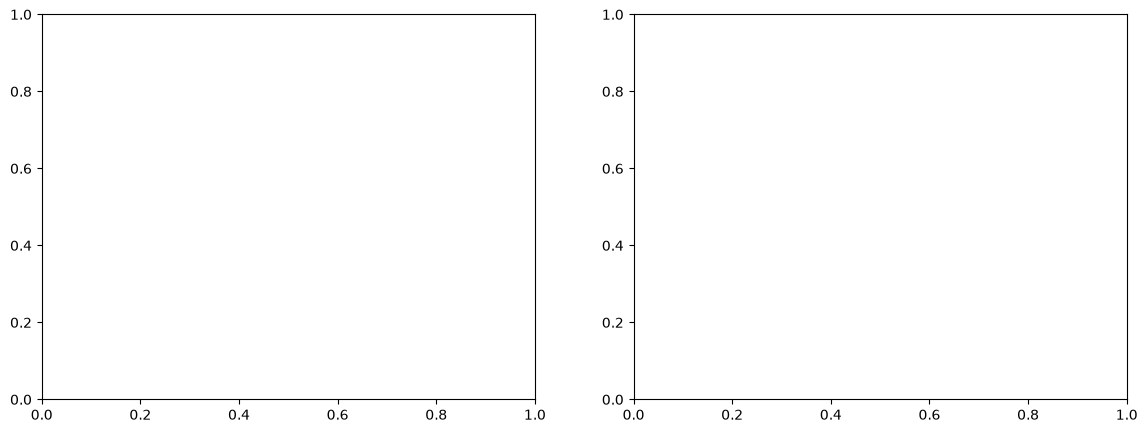

In [10]:

# ================================================================================
# CELL 8 — Plot training curves
# ================================================================================
# Training curves show how the model improved over epochs.
# If training accuracy is much higher than validation accuracy, the model is overfitting.
# If both are low, the model is underfitting.
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Accuracy curve
axes[0].plot(history.history["accuracy"],
             label="Train Accuracy", color="#2196F3", linewidth=2)
axes[0].plot(history.history["val_accuracy"],
             label="Val Accuracy", color="#FF9800", linewidth=2, linestyle="--")
axes[0].set_title("Model Accuracy over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_ylim(0, 1)
 
# Loss curve
axes[1].plot(history.history["loss"],
             label="Train Loss", color="#4CAF50", linewidth=2)
axes[1].plot(history.history["val_loss"],
             label="Val Loss", color="#F44336", linewidth=2, linestyle="--")
axes[1].set_title("Model Loss over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
 
plt.suptitle("Baseline CNN — Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model1_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model1_training_history.png")

In [11]:

# ================================================================================
# CELL 9 — Evaluate the model on the test set
# ================================================================================
# We evaluate on the test generator which the model has NEVER seen during training.
# This gives us an unbiased estimate of real-world performance.
 
print("Evaluating model on test set...")
print("-" * 40)
 
# Get predictions from the model
test_gen.reset()   # reset generator to start from beginning
y_pred_probs = model.predict(test_gen, verbose=1)   # predicted probabilities
y_pred       = np.argmax(y_pred_probs, axis=1)      # predicted class index
y_true       = test_gen.classes                      # true class labels
 
# Core metrics
accuracy = accuracy_score(y_true, y_pred)
f1       = f1_score(y_true, y_pred, average="weighted")
 
# ROC-AUC score — needs one-hot encoded true labels
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=N_CLASSES)
roc_auc       = roc_auc_score(y_true_onehot, y_pred_probs,
                               multi_class="ovr", average="weighted")
 
print(f"\n  Accuracy  : {accuracy:.4f}  (KPI target ≥ 0.85)")
print(f"  F1 Score  : {f1:.4f}  (KPI target ≥ 0.85)")
print(f"  ROC-AUC   : {roc_auc:.4f}  (KPI target ≥ 0.90)")
 
# Check which KPIs are met
print("\n  KPI Status:")
print(f"  Accuracy  {'✅ MET' if accuracy >= 0.85 else '❌ NOT MET'}")
print(f"  F1 Score  {'✅ MET' if f1 >= 0.85 else '❌ NOT MET'}")
print(f"  ROC-AUC   {'✅ MET' if roc_auc >= 0.90 else '❌ NOT MET'}")
 
 
# ================================================================================
# CELL 10 — Classification report
# ================================================================================
# Shows precision, recall and F1 per class so we can see which dementia
# stages the model struggles with — important for fairness analysis
 
print("\n  Classification Report:")
print("-" * 50)
print(classification_report(y_true, y_pred, target_names=CLASSES))
 

Evaluating model on test set...
----------------------------------------


NameError: name 'test_gen' is not defined

In [12]:

# ================================================================================
# CELL 11 — Confusion matrix
# ================================================================================
# Confusion matrix shows exactly which classes are being confused with each other.
# Rows = actual class, Columns = predicted class.
# A perfect model has all values on the diagonal.
 
cm = confusion_matrix(y_true, y_pred)
 
# Normalise by row so each cell shows the percentage of that class correctly predicted
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Raw Counts)", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=15)
 
# Normalised percentages
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Normalised)", fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=15)
 
plt.suptitle("Baseline CNN — Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model1_confusion_matrix.png")

NameError: name 'y_true' is not defined

In [13]:

# ================================================================================
# CELL 12 — Save predictions for fairness evaluation later
# ================================================================================
# We save the raw predictions to a CSV file so we can use them in the
# fairness evaluation notebook without rerunning the whole model.
# This includes predicted probabilities for each class and the final prediction.
 
predictions_df = pd.DataFrame(
    y_pred_probs,
    columns=[f"prob_{cls}" for cls in CLASSES]
)
predictions_df["predicted_class"]  = y_pred
predictions_df["predicted_label"]  = [CLASSES[i] for i in y_pred]
predictions_df["true_class"]       = y_true
predictions_df["true_label"]       = [CLASSES[i] for i in y_true]
predictions_df["correct"]          = (y_pred == y_true)
 
# Save to CSV
pred_path = RESULTS_DIR / "model1_predictions.csv"
predictions_df.to_csv(pred_path, index=False)
print(f"Predictions saved to: {pred_path}")
print(f"Shape: {predictions_df.shape}")
print(predictions_df.head())
 

NameError: name 'y_pred_probs' is not defined

In [14]:

# ================================================================================
# CELL 13 — Save the final model
# ================================================================================
# Save the full model so we can load it later for:
#   - Grad-CAM visualisation (explainability)
#   - Fairness evaluation
#   - Comparison with Model 2 and Model 3
 
final_model_path = MODELS_DIR / "model1_baseline_cnn_final.h5"
model.save(str(final_model_path))
print(f"Final model saved to: {final_model_path}")

WARNING | You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Final model saved to: ..\results\models\model1_baseline_cnn_final.h5


In [ ]:

# ================================================================================
# CELL 14 — Final summary
# ================================================================================
# Brings together all results so the team can compare against KPIs
# and make decisions about the next model
 
print("\n" + "=" * 60)
print("  MODEL 1 — BASELINE CNN SUMMARY")
print("=" * 60)
print(f"""
  ARCHITECTURE
  ------------
  Type        : CNN trained from scratch
  Input size  : {IMG_HEIGHT}x{IMG_WIDTH}x3
  Conv blocks : 4 (32 → 64 → 128 → 256 filters)
  Parameters  : {model.count_params():,}
 
  TRAINING
  --------
  Epochs run  : {len(history.history['loss'])}
  Best val acc: {max(history.history['val_accuracy']):.4f}
  Best val loss: {min(history.history['val_loss']):.4f}
 
  TEST SET RESULTS
  ----------------
  Accuracy    : {accuracy:.4f}  (KPI: ≥ 0.85)  {'✅' if accuracy >= 0.85 else '❌'}
  F1 Score    : {f1:.4f}  (KPI: ≥ 0.85)  {'✅' if f1 >= 0.85 else '❌'}
  ROC-AUC     : {roc_auc:.4f}  (KPI: ≥ 0.90)  {'✅' if roc_auc >= 0.90 else '❌'}
 
  SAVED FILES
  -----------
  Model (best)  : results/models/model1_baseline_cnn_best.h5
  Model (final) : results/models/model1_baseline_cnn_final.h5
  Predictions   : results/model1_predictions.csv
  Plots         : results/plots/model1_training_history.png
                  results/plots/model1_confusion_matrix.png
 
  NEXT STEP: Model2_TransferLearning.ipynb
""")
 